# Comparison of Low-Light Image Enhancement Techniques
## *Comparación de tecnicas de realce de imágenes de baja iluminación*

Project workflow / *Flujo de trabajo del proyecto*

| # | EN | ES |
|---|---------|---------|
| 1 | Run YOLO on the original image and store the results | Ejecuta YOLO en la imagen original y guarda los resultados |
| 2 | Apply an enhancement technique to the original image | Aplica una técnica de realce a la imagen original |
| 3 | Run YOLO on the modified image | Ejecuta YOLO en la imagen modificada |
| 4 | Show a comparison of the images | Muestra una comparación de las imágenes |
| 5 | Calculate the computational cost | Calcula el coste computacional |

In [424]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import gc

## Variables and functions configuration
### *Configuracion de variables y funciones*

In [ ]:
imgPath = './imgsPruebas/image7.jpg' #/mnt/datos_compartidos/TesisArchivos/Original/imagenesOTROS/imgOTROS_737.jpg'
modelPath = "./runs/detect/YOLOv9/weights/best.pt"

img = cv2.cvtColor(cv2.imread(imgPath), cv2.COLOR_BGR2RGB)
model = YOLO(modelPath)

fontTitle = 16

In [426]:
def detectYOLO(imgInput):  # Define function to run YOLO detection on an image / Definir función para ejecutar detección YOLO en una imagen
    result = model(imgInput, imgsz=640, verbose=True, conf=0.3, iou=0.7)[0]  # Run YOLO model and get first result / Ejecutar modelo YOLO y obtener primer resultado
    return result.plot()  # Return image with detections plotted / Devolver imagen con detecciones dibujadas

def showComparison(imgOrig, imgMod, titleOrig = "", titleMod = "", saveImg = False, saveName = "imgComparison.pdf"):  # Define function to compare two images / Definir función para comparar dos imágenes
    plt.figure(figsize=(12, 8))  # Create new figure with size 12x8 / Crear nueva figura con tamaño 12x8

    plt.subplot(1, 2, 1)  # Create first subplot (1 row, 2 columns, position 1) / Crear primer subplot (1 fila, 2 columnas, posición 1)
    plt.title(titleOrig, fontsize = fontTitle)  # Set title for original image / Establecer título para imagen original
    plt.imshow(imgOrig)  # Display original image / Mostrar imagen original
    plt.axis('off')  # Hide axes / Ocultar ejes

    plt.subplot(1, 2, 2)  # Create second subplot (1 row, 2 columns, position 2) / Crear segundo subplot (1 fila, 2 columnas, posición 2)
    plt.title(titleMod, fontsize = fontTitle)  # Set title for modified image / Establecer título para imagen modificada
    plt.imshow(imgMod)  # Display modified image / Mostrar imagen modificada
    plt.axis('off')  # Hide axes / Ocultar ejes
    
    plt.tight_layout()  # Adjust layout to prevent overlap / Ajustar diseño para evitar superposición
    if saveImg:  # If saving is enabled / Si guardar está habilitado
        plt.savefig(saveName, dpi=300, bbox_inches='tight')  # Save figure / Guardar figura
    plt.show()  # Show the figure / Mostrar la figura

## Show image
### *Mostrar imagen*


0: 480x640 3 vehiculos, 137.9ms
Speed: 4.7ms preprocess, 137.9ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)


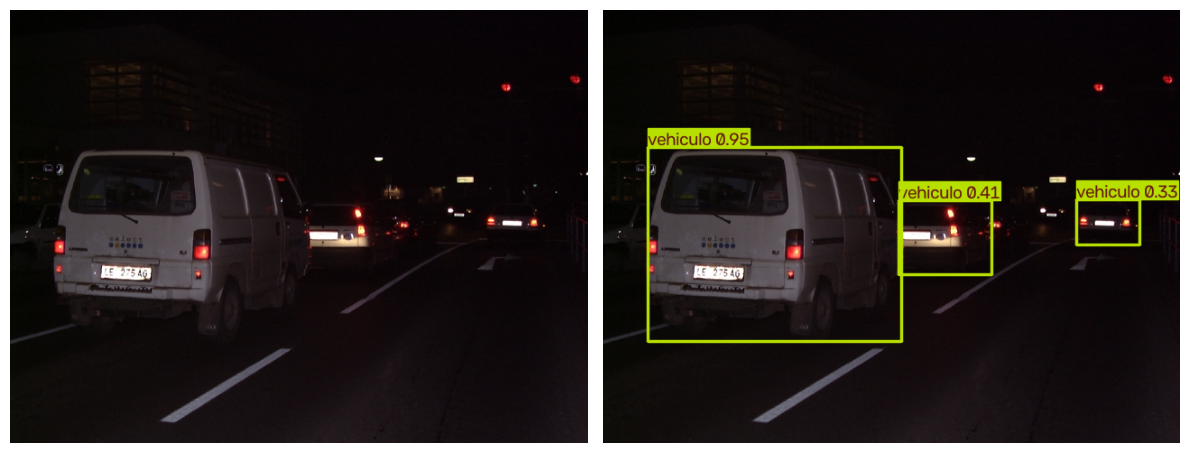

In [427]:
imgDetectOriginal = detectYOLO(img)  # Run YOLO detection on the image and store plotted result / Ejecutar detección YOLO en la imagen y almacenar el resultado dibujado

showComparison(img, imgDetectOriginal)  # Show comparison between original and detected image / Mostrar comparación entre imagen original y detectada

## Comparison Techniques
### *Comparar técnicas*

### Simple Histogram Equalization (YCrCb)
#### *Ecualización de Histograma simple (YCrCb)*


0: 480x640 4 vehiculos, 1 senializacion, 137.8ms
Speed: 2.7ms preprocess, 137.8ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)


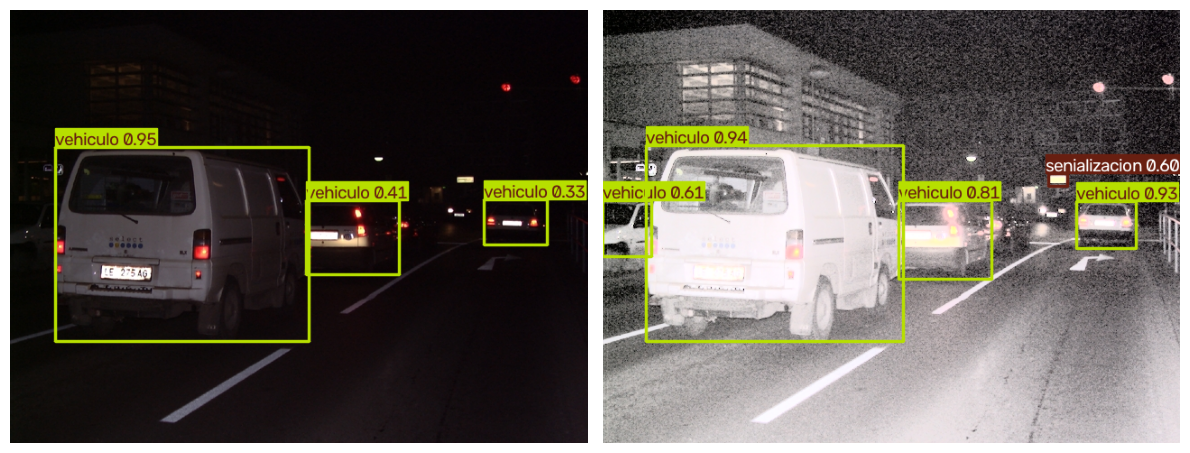

In [428]:
img_ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)  # Convert image from RGB to YCrCb color space / Convertir imagen de RGB a espacio de color YCrCb
Y, Cr, Cb = cv2.split(img_ycrcb)  # Split YCrCb image into Y, Cr, Cb channels / Dividir imagen YCrCb en canales Y, Cr, Cb

Y_equalized = cv2.equalizeHist(Y)  # Apply histogram equalization to Y channel / Aplicar ecualización de histograma al canal Y

img_equalized_ycrcb = cv2.merge([Y_equalized, Cr, Cb])  # Merge equalized Y with original Cr, Cb channels / Fusionar Y ecualizado con canales Cr, Cb originales

img_hist_equalized_color = cv2.cvtColor(img_equalized_ycrcb, cv2.COLOR_YCrCb2RGB)  # Convert back from YCrCb to RGB color space / Convertir de vuelta de YCrCb a espacio de color RGB

showComparison(imgDetectOriginal, detectYOLO(img_hist_equalized_color))  # Compare original detection with detection on equalized image / Comparar detección original con detección en imagen ecualizada

In [429]:
%%timeit -r 5 -n 50  # Jupyter magic: measure execution time, 5 runs of 50 loops each / Magic de Jupyter: medir tiempo de ejecución, 5 ejecuciones de 50 bucles cada una

img_ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)  # Convert image from RGB to YCrCb color space / Convertir imagen de RGB a espacio de color YCrCb
Y, Cr, Cb = cv2.split(img_ycrcb)  # Split YCrCb image into Y, Cr, Cb channels / Dividir imagen YCrCb en canales Y, Cr, Cb
Y_equalized = cv2.equalizeHist(Y)  # Apply histogram equalization to Y channel / Aplicar ecualización de histograma al canal Y
img_equalized_ycrcb = cv2.merge([Y_equalized, Cr, Cb])  # Merge equalized Y with original Cr, Cb channels / Fusionar Y ecualizado con canales Cr, Cb originales
img_hist_equalized_color = cv2.cvtColor(img_equalized_ycrcb, cv2.COLOR_YCrCb2RGB)  # Convert back from YCrCb to RGB / Convertir de vuelta de YCrCb a RGB

1.79 ms ± 116 μs per loop (mean ± std. dev. of 5 runs, 50 loops each)


In [430]:
del img_ycrcb, Y, Cr, Cb, Y_equalized, img_equalized_ycrcb, img_hist_equalized_color  # Delete intermediate variables to free memory / Eliminar variables intermedias para liberar memoria
gc.collect()  # Force garbage collector to release unused memory / Forzar el recolector de basura para liberar memoria no usada

12901

### Simple Histogram Equalization (HSV)
#### *Ecualización de Histograma simple (HSV)*


0: 480x640 4 vehiculos, 2 senializacions, 1 basurero, 215.5ms
Speed: 6.0ms preprocess, 215.5ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)


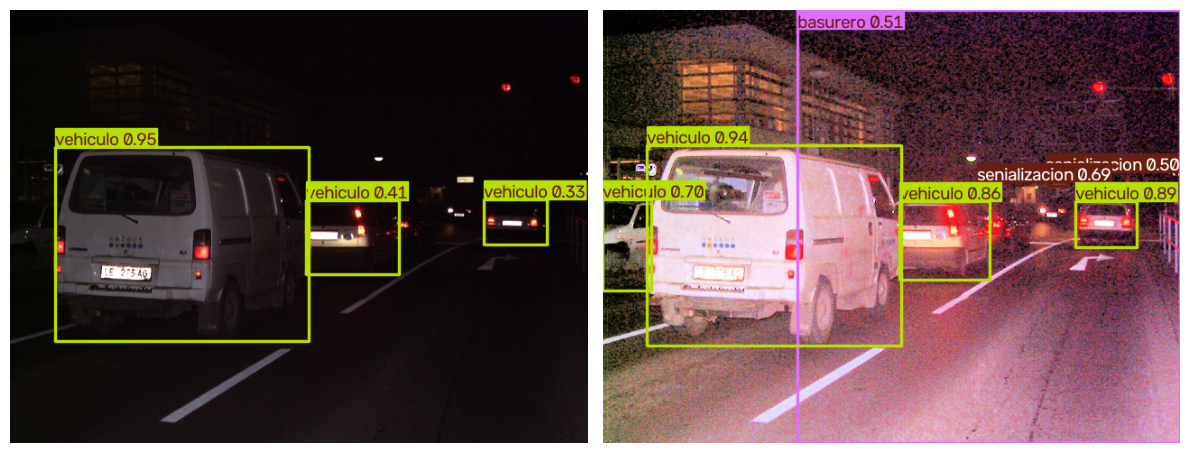

In [431]:
img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)  # Convert image from RGB to HSV color space / Convertir imagen de RGB a espacio de color HSV
H, S, V = cv2.split(img_hsv)  # Split HSV image into H, S, V channels / Dividir imagen HSV en canales H, S, V

V_equalized = cv2.equalizeHist(V)  # Apply histogram equalization to V channel / Aplicar ecualización de histograma al canal V

img_equalized_hsv = cv2.merge([H, S, V_equalized])  # Merge H, S with equalized V channel / Fusionar H, S con el canal V ecualizado

img_hist_equalized_color_hsv = cv2.cvtColor(img_equalized_hsv, cv2.COLOR_HSV2RGB)  # Convert back from HSV to RGB color space / Convertir de vuelta de HSV a espacio de color RGB

showComparison(imgDetectOriginal, detectYOLO(img_hist_equalized_color_hsv))  # Compare original detection with detection on HSV-equalized image / Comparar detección original con detección en imagen ecualizada en HSV

In [432]:
%%timeit -r 5 -n 50  # Jupyter magic: measure execution time, 5 runs of 50 loops each / Magic de Jupyter: medir tiempo de ejecución, 5 ejecuciones de 50 bucles cada una
img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)  # Convert image from RGB to HSV color space / Convertir imagen de RGB a espacio de color HSV
H, S, V = cv2.split(img_hsv)  # Split HSV image into H, S, V channels / Dividir imagen HSV en canales H, S, V
V_equalized = cv2.equalizeHist(V)  # Apply histogram equalization to V channel / Aplicar ecualización de histograma al canal V
img_equalized_hsv = cv2.merge([H, S, V_equalized])  # Merge H, S with equalized V channel / Fusionar H, S con el canal V ecualizado
img_hist_equalized_color_hsv = cv2.cvtColor(img_equalized_hsv, cv2.COLOR_HSV2RGB)  # Convert back from HSV to RGB / Convertir de vuelta de HSV a RGB

2.61 ms ± 227 μs per loop (mean ± std. dev. of 5 runs, 50 loops each)


In [433]:
del img_hsv, H, S, V, V_equalized, img_equalized_hsv, img_hist_equalized_color_hsv  # Delete intermediate variables to free memory / Eliminar variables intermedias para liberar memoria
gc.collect()  # Force garbage collector to release unused memory / Forzar el recolector de basura para liberar memoria no usada

3144

### Adaptive Histogram Equalization (CLAHE - YCrCb)
#### *Ecualización de Histograma Adaptativa (CLAHE - YCrCb)*


0: 480x640 4 vehiculos, 2 senializacions, 131.4ms
Speed: 9.4ms preprocess, 131.4ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)


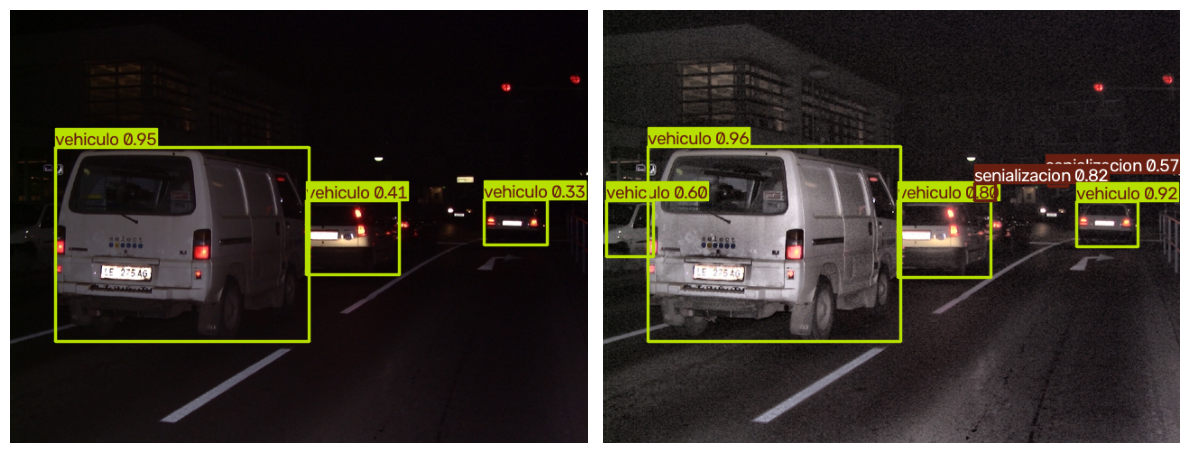

In [434]:
img_ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)  # Convert image from RGB to YCrCb color space / Convertir imagen de RGB a espacio de color YCrCb
Y, Cr, Cb = cv2.split(img_ycrcb)  # Split YCrCb image into Y, Cr, Cb channels / Dividir imagen YCrCb en canales Y, Cr, Cb

clahe_obj = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(8, 8))  # Create CLAHE object with clip limit and tile grid / Crear objeto CLAHE con límite de recorte y tamaño de mosaico
Y_clahe = clahe_obj.apply(Y)  # Apply CLAHE to Y channel / Aplicar CLAHE al canal Y

img_clahe_ycrcb = cv2.merge([Y_clahe, Cr, Cb])  # Merge CLAHE-enhanced Y with original Cr, Cb channels / Fusionar Y mejorado con CLAHE con canales Cr, Cb originales

img_clahe_color = cv2.cvtColor(img_clahe_ycrcb, cv2.COLOR_YCrCb2RGB)  # Convert back from YCrCb to RGB color space / Convertir de vuelta de YCrCb a espacio de color RGB

showComparison(imgDetectOriginal, detectYOLO(img_clahe_color))  # Compare original detection with detection on CLAHE-enhanced image / Comparar detección original con detección en imagen mejorada con CLAHE

In [435]:
%%timeit -r 5 -n 50  # Jupyter magic: measure execution time, 5 runs of 50 loops each / Magic de Jupyter: medir tiempo de ejecución, 5 ejecuciones de 50 bucles cada una
img_ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)  # Convert image from RGB to YCrCb color space / Convertir imagen de RGB a espacio de color YCrCb
Y, Cr, Cb = cv2.split(img_ycrcb)  # Split YCrCb image into Y, Cr, Cb channels / Dividir imagen YCrCb en canales Y, Cr, Cb
Y_clahe = clahe_obj.apply(Y)  # Apply CLAHE to Y channel / Aplicar CLAHE al canal Y
img_clahe_ycrcb = cv2.merge([Y_clahe, Cr, Cb])  # Merge CLAHE-enhanced Y with original Cr, Cb channels / Fusionar Y mejorado con CLAHE con canales Cr, Cb originales
img_clahe_color = cv2.cvtColor(img_clahe_ycrcb, cv2.COLOR_YCrCb2RGB)  # Convert back from YCrCb to RGB / Convertir de vuelta de YCrCb a RGB

3.11 ms ± 230 μs per loop (mean ± std. dev. of 5 runs, 50 loops each)


In [436]:
del img_ycrcb, Y, Cr, Cb, Y_clahe, clahe_obj, img_clahe_ycrcb, img_clahe_color  # Delete intermediate variables to free memory / Eliminar variables intermedias para liberar memoria
gc.collect()  # Force garbage collector to release unused memory / Forzar el recolector de basura para liberar memoria no usada

3144

### Adaptive Histogram Equalization (CLAHE - HSV)
#### *Ecualización de Histograma Adaptativa (CLAHE - HSV)*


0: 480x640 3 vehiculos, 2 senializacions, 253.1ms
Speed: 8.9ms preprocess, 253.1ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)


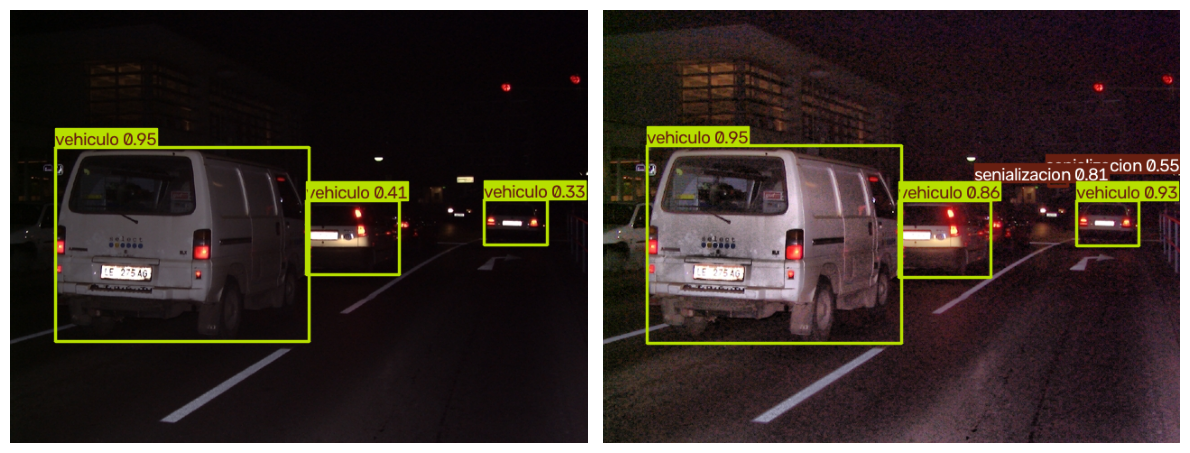

In [437]:
img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)  # Convert image from RGB to HSV color space / Convertir imagen de RGB a espacio de color HSV
H, S, V = cv2.split(img_hsv)  # Split HSV image into H, S, V channels / Dividir imagen HSV en canales H, S, V

clahe_obj = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(8, 8))  # Create CLAHE object with clip limit and tile grid / Crear objeto CLAHE con límite de recorte y tamaño de mosaico
V_clahe = clahe_obj.apply(V)  # Apply CLAHE to V channel / Aplicar CLAHE al canal V

img_clahe_hsv = cv2.merge([H, S, V_clahe])  # Merge H, S with CLAHE-enhanced V channel / Fusionar H, S con el canal V mejorado con CLAHE

img_clahe_color_hsv = cv2.cvtColor(img_clahe_hsv, cv2.COLOR_HSV2RGB)  # Convert back from HSV to RGB color space / Convertir de vuelta de HSV a espacio de color RGB

showComparison(imgDetectOriginal, detectYOLO(img_clahe_color_hsv))  # Compare original detection with detection on HSV-CLAHE image / Comparar detección original con detección en imagen HSV-CLAHE

In [438]:
%%timeit -r 5 -n 50  # Jupyter magic: measure execution time, 5 runs of 50 loops each / Magic de Jupyter: medir tiempo de ejecución, 5 ejecuciones de 50 bucles cada una
img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)  # Convert image from RGB to HSV color space / Convertir imagen de RGB a espacio de color HSV
H, S, V = cv2.split(img_hsv)  # Split HSV image into H, S, V channels / Dividir imagen HSV en canales H, S, V
V_clahe = clahe_obj.apply(V)  # Apply CLAHE to V channel / Aplicar CLAHE al canal V
img_clahe_hsv = cv2.merge([H, S, V_clahe])  # Merge H, S with CLAHE-enhanced V channel / Fusionar H, S con el canal V mejorado con CLAHE
img_clahe_color_hsv = cv2.cvtColor(img_clahe_hsv, cv2.COLOR_HSV2RGB)  # Convert back from HSV to RGB / Convertir de vuelta de HSV a RGB

3.76 ms ± 154 μs per loop (mean ± std. dev. of 5 runs, 50 loops each)


In [439]:
del img_hsv, H, S, V, V_clahe, clahe_obj, img_clahe_hsv, img_clahe_color_hsv  # Delete intermediate variables to free memory / Eliminar variables intermedias para liberar memoria
gc.collect()  # Force garbage collector to release unused memory / Forzar el recolector de basura para liberar memoria no usada

3144

### Gamma Correction
#### *Corrección Gamma*


0: 480x640 4 vehiculos, 2 senializacions, 152.4ms
Speed: 5.2ms preprocess, 152.4ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)


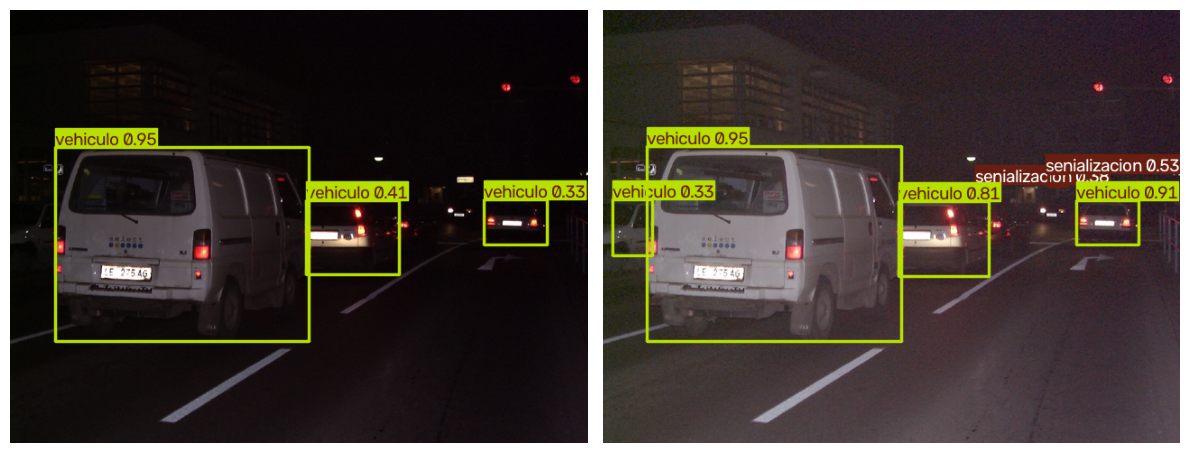

In [440]:
gamma = 0.5  # Set gamma correction value / Establecer valor de corrección gamma

gamma_table = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")  # Build lookup table for gamma correction / Construir tabla de búsqueda para corrección gamma

img_gamma = cv2.LUT(img, gamma_table)  # Apply gamma correction using lookup table / Aplicar corrección gamma usando tabla de búsqueda

showComparison(imgDetectOriginal, detectYOLO(img_gamma))  # Compare original detection with detection on gamma-corrected image / Comparar detección original con detección en imagen con corrección gamma

In [441]:
%%timeit -r 5 -n 50  # Jupyter magic: measure execution time, 5 runs of 50 loops each / Magic de Jupyter: medir tiempo de ejecución, 5 ejecuciones de 50 bucles cada una
img_gamma = cv2.LUT(img, gamma_table)  # Apply gamma correction using precomputed lookup table / Aplicar corrección gamma usando tabla de búsqueda precalculada

440 μs ± 73.3 μs per loop (mean ± std. dev. of 5 runs, 50 loops each)


In [442]:
del gamma, gamma_table, img_gamma  # Delete intermediate variables to free memory / Eliminar variables intermedias para liberar memoria
gc.collect()  # Force garbage collector to release unused memory / Forzar el recolector de basura para liberar memoria no usada

3144

### Linear Adjustment
#### *Ajuste lineal*


0: 480x640 3 vehiculos, 141.3ms
Speed: 9.2ms preprocess, 141.3ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)


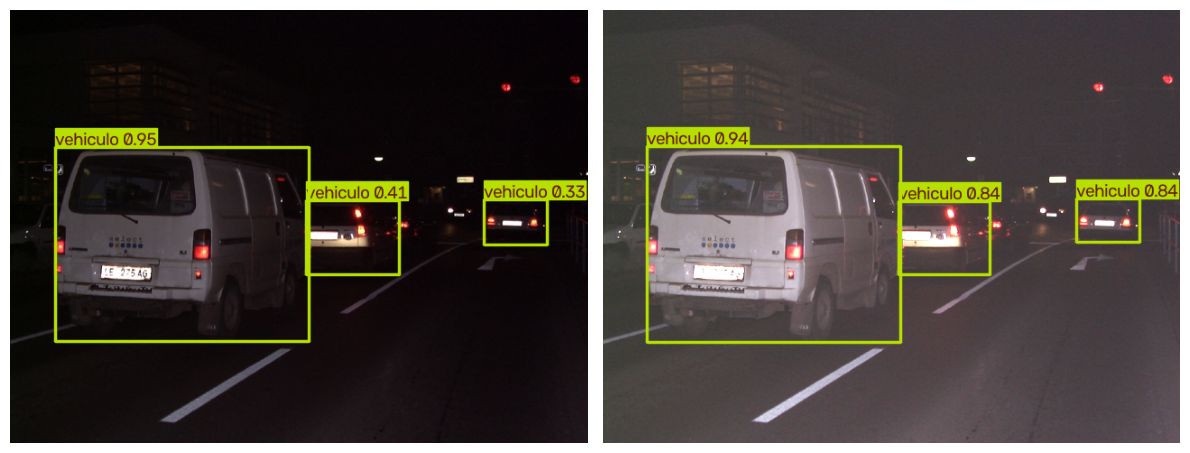

In [443]:
alpha = 1.5  # Contrast factor (1.0 = no change) / Factor de contraste (1.0 = sin cambio)
beta = 50  # Brightness offset added to each pixel / Desplazamiento de brillo sumado a cada píxel

img_brillo_contraste = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)  # Apply brightness/contrast scaling with saturation to 8-bit / Aplicar escalado de brillo/contraste con saturación a 8 bits

showComparison(imgDetectOriginal, detectYOLO(img_brillo_contraste))  # Compare original detection with detection on brightened image / Comparar detección original con detección en imagen con brillo ajustado

In [444]:
%%timeit -r 5 -n 50  # Jupyter magic: measure execution time, 5 runs of 50 loops each / Magic de Jupyter: medir tiempo de ejecución, 5 ejecuciones de 50 bucles cada una
img_brillo_contraste = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)  # Apply brightness/contrast scaling / Aplicar escalado de brillo/contraste

304 μs ± 35.6 μs per loop (mean ± std. dev. of 5 runs, 50 loops each)


In [445]:
del alpha, beta, img_brillo_contraste  # Delete intermediate variables to free memory / Eliminar variables intermedias para liberar memoria
gc.collect()  # Force garbage collector to release unused memory / Forzar el recolector de basura para liberar memoria no usada

3144